# Quantization Benchmark Lab

This companion to `L4.ipynb` turns a demonstration into a reproducible experiment. It does not promise a universally best quantizer: results apply to the model, runtime, hardware and workload tested.

## Learning route
1. Configure and freeze an experiment; validate the measurement before running a large model.
2. Resolve complete checkpoints, inspect calibration data, optionally build new GPTQ variants.
3. Compare storage, repeated Transformers generation and held-out perplexity in fresh processes.
4. Evaluate real tasks with EleutherAI's harness; analyze paired differences and uncertainty.
5. Benchmark vLLM serving under concurrency and arrival-rate sweeps; inspect goodput, memory and latency curves.
6. Export evidence and decide pass, fail or inconclusive against preregistered limits.

## Dependencies and safety
Use the repo's existing environment for Torch, Transformers, datasets, llm-compressor, compressed-tensors, NumPy, pandas, matplotlib and psutil. Torch executes tensors; Transformers loads models; datasets prepares text; the compressor chooses quantized values; compressed-tensors stores/loads their representation. Do not blindly upgrade Torch on DGX Spark: ARM64/CUDA compatibility matters.

Optional task evaluation: install `lm_eval[hf]` and task extras such as `lm_eval[ifeval]` using the selected environment's package manager. Install vLLM using its [hardware-specific instructions](https://docs.vllm.ai/en/stable/getting_started/installation/gpu/), preferably in a separate compatible environment/container. Set `VLLM_PYTHON` and `LM_EVAL_PYTHON` below if needed. A container requires adapting the explicit command launcher and volume mounts, not assuming the notebook environment is shared.

The default **smoke** profile is diagnostic only. `Run All` executes CPU tests and explanatory diagrams but does not download models, quantize, start servers or run costly benchmarks. Set individual `RUN_*` switches as you progress. For final results use `PROFILE='full'`, review thresholds *before* running, and restart the kernel. Re-running configuration creates a new results directory; do not mix different experiments in one directory.

Cache variables are set before model-library imports in a fresh kernel. Seeds reduce random variation but do not guarantee identical results across GPU architectures, kernels or batch sizes. Close models running in other notebooks before measuring. Hardware detection is not proof that a particular INT4 kernel is supported: start with a smoke run and inspect its logs.

## Why test perplexity first?
For overlapping windows each token after the first must be scored exactly once. The denominator counts valid **shifted** labels, not input length. Mask context-only targets with `-100`.

$$\mathrm{PPL}=\exp\left(\frac{\sum_j n_j L_j}{\sum_j n_j}\right)$$

$L_j$ is mean cross-entropy in window $j$; $n_j$ counts actual scored tokens. The tiny randomly initialized model below needs no download. We compare against independent token-wise log probabilities, including the short final window.

In [3]:
import os
import sys
import json
import hashlib
import pathlib
import platform
import subprocess
import importlib.metadata
from datetime import datetime, timezone

ROOT = next(path for path in [pathlib.Path.cwd(), *pathlib.Path.cwd().parents]
            if (path / 'Compressor' / 'L4.ipynb').exists())
NOTEBOOK = ROOT / 'Compressor' / 'Benchmark_Lab.ipynb'
CACHE = pathlib.Path(os.environ.get('HF_HOME', ROOT / 'Compressor' / '.hf-cache')).resolve()
os.environ['HF_HOME'] = str(CACHE)
os.environ['HF_HUB_CACHE'] = str(CACHE / 'hub')
os.environ['HF_DATASETS_CACHE'] = str(CACHE / 'datasets')
os.environ['TOKENIZERS_PARALLELISM'] = 'false'

PROFILE = 'smoke'
RUN_PREPARE = False
RUN_QUANTIZE = False
RUN_LOCAL = False
RUN_TASKS = False
RUN_SERVING = False
RUN_SWEEP = False
BASE_REVISION = os.environ.get('BASE_REVISION', 'main')
DATA_REVISION = os.environ.get('DATA_REVISION', 'main')
MODELS = {
    'reference': {'path': 'Qwen/Qwen3-8B', 'revision': BASE_REVISION},
    'gptq': {'path': str(ROOT / 'models' / 'Qwen3-8B-W4A16'), 'revision': None},
}
AWQ_PATH = os.environ.get('AWQ_PATH')
if AWQ_PATH:
    MODELS['awq'] = {'path': AWQ_PATH, 'revision': None}

CFG = {
    'profile': PROFILE, 'seed': 42, 'calibration_samples': 256, 'calibration_context': 2048,
    'group_size': 128, 'context': 2048, 'stride': 512,
    'max_eval_tokens': 5000 if PROFILE == 'smoke' else None,
    'generation_tokens': 64 if PROFILE == 'smoke' else 256,
    'warmups': 2, 'repetitions': 2 if PROFILE == 'smoke' else 5,
    'requests': 8 if PROFILE == 'smoke' else 1000,
    'task_limit': 10 if PROFILE == 'smoke' else None,
    'enable_thinking': False, 'temperature': 0.7, 'top_p': 0.8, 'top_k': 20,
    'dataset': 'Salesforce/wikitext', 'dataset_config': 'wikitext-2-raw-v1',
    'dataset_revision': DATA_REVISION, 'cache': str(CACHE),
    'max_ppl_increase_pct': 5.0, 'max_accuracy_drop_pp': 1.0,
    'ttft_ms': 2000, 'tpot_ms': 100, 'min_goodput_fraction': 0.95,
    'max_failure_fraction': 0.0, 'placement': 'cuda:0',
}
assert PROFILE in {'smoke', 'full'}
assert 0 < CFG['stride'] < CFG['context']
RUN_ID = datetime.now(timezone.utc).strftime('%Y%m%dT%H%M%S%fZ')
RESULTS = ROOT / 'Compressor' / 'benchmark_results' / RUN_ID
RESULTS.mkdir(parents=True, exist_ok=False)
packages = ['torch', 'transformers', 'datasets', 'llmcompressor', 'compressed-tensors',
            'numpy', 'pandas', 'matplotlib', 'psutil', 'huggingface-hub', 'vllm', 'lm_eval']
VERSIONS = {}
for package in packages:
    try:
        VERSIONS[package] = importlib.metadata.version(package)
    except importlib.metadata.PackageNotFoundError:
        VERSIONS[package] = None
manifest = {'run_id': RUN_ID, 'settings': CFG, 'models': MODELS, 'versions': VERSIONS,
            'python': sys.version, 'executable': sys.executable, 'platform': platform.platform()}
(RESULTS / 'manifest.json').write_text(json.dumps(manifest, indent=2))
print(json.dumps(manifest, indent=2))
print('Run All is safe: expensive switches are False. Results:', RESULTS)

{
  "run_id": "20260912T182055318674Z",
  "settings": {
    "profile": "smoke",
    "seed": 42,
    "calibration_samples": 256,
    "calibration_context": 2048,
    "group_size": 128,
    "context": 2048,
    "stride": 512,
    "max_eval_tokens": 5000,
    "generation_tokens": 64,
    "warmups": 2,
    "repetitions": 2,
    "requests": 8,
    "task_limit": 10,
    "enable_thinking": false,
    "temperature": 0.7,
    "top_p": 0.8,
    "top_k": 20,
    "dataset": "Salesforce/wikitext",
    "dataset_config": "wikitext-2-raw-v1",
    "dataset_revision": "main",
    "cache": "/home/nizare/InferenceOptimizer/Compressor/.hf-cache",
    "max_ppl_increase_pct": 5.0,
    "max_accuracy_drop_pp": 1.0,
    "ttft_ms": 2000,
    "tpot_ms": 100,
    "min_goodput_fraction": 0.95,
    "max_failure_fraction": 0.0,
    "placement": "cuda:0"
  },
  "models": {
    "reference": {
      "path": "Qwen/Qwen3-8B",
      "revision": "main"
    },
    "gptq": {
      "path": "/home/nizare/InferenceOptimizer/mode

In [16]:
GATES = {'target_arrival_rps': 0.5, 'minimum_system_available_gib': 8.0,
         'maximum_weight_ratio': 0.6, 'minimum_task_examples': 100,
         'require_private_task': False}
CFG['task_generation_tokens'] = 512 if PROFILE == 'smoke' else 2048
manifest['settings'] = CFG
manifest['gates'] = GATES
(RESULTS / 'manifest.json').write_text(json.dumps(manifest, indent=2))
print('Illustrative acceptance limits: review BEFORE enabling expensive runs.', GATES)

Illustrative acceptance limits: review BEFORE enabling expensive runs. {'target_arrival_rps': 0.5, 'minimum_system_available_gib': 8.0, 'maximum_weight_ratio': 0.6, 'minimum_task_examples': 100, 'require_private_task': False}


In [1]:
import math
import torch

def scoring_windows(length, context, stride):
    if length < 2 or context < 2 or not 0 < stride < context:
        raise ValueError('Need length >= 2 and 0 < stride < context.')
    previous_end = 0
    for begin in range(0, length, stride):
        end = min(begin + context, length)
        first_target = max(previous_end, begin + 1)
        if first_target < end:
            yield begin, end, first_target
        previous_end = end
        if end == length:
            break

def sliding_perplexity(model, token_ids, context=2048, stride=512):
    if token_ids.ndim != 2 or token_ids.shape[0] != 1:
        raise ValueError('Expected one unpadded token sequence.')
    model.eval()
    device = model.get_input_embeddings().weight.device
    total_nll, total_scored = 0.0, 0
    records = []
    for begin, end, first_target in scoring_windows(token_ids.shape[1], context, stride):
        inputs = token_ids[:, begin:end].to(device)
        labels = inputs.clone()
        labels[:, :first_target - begin] = -100
        count = int((labels[:, 1:] != -100).sum().item())
        if not count:
            continue
        with torch.inference_mode():
            loss = float(model(inputs, labels=labels, use_cache=False).loss.float().item())
        if not math.isfinite(loss):
            raise ValueError('Non-finite loss; inspect model/backend before reporting.')
        total_nll += loss * count
        total_scored += count
        records.append({'begin': begin, 'end': end, 'scored': count, 'nll': loss * count})
    assert total_scored == token_ids.shape[1] - 1
    return {'ppl': math.exp(total_nll / total_scored), 'mean_nll': total_nll / total_scored,
            'scored_tokens': total_scored, 'context': context, 'stride': stride, 'windows': records}

In [20]:
from transformers import GPT2Config, GPT2LMHeadModel


def test_perplexity():
    for length in (2, 7, 8, 9, 17, 25):
        for stride in (1, 3, 7):
            scored = [position for _, end, first in scoring_windows(length, 8, stride)
                      for position in range(first, end)]
            assert scored == list(range(1, length))
    with torch.random.fork_rng(devices=[]):
        torch.manual_seed(42)
        tiny = GPT2LMHeadModel(GPT2Config(vocab_size=32, n_positions=16, n_embd=16, n_layer=1, n_head=2,
                                       bos_token_id=0, eos_token_id=1, pad_token_id=31)).eval()
    tokens = torch.tensor([[1, 4, 7, 3, 9, 2, 8]])
    with torch.inference_mode():
        direct = math.exp(float(tiny(tokens, labels=tokens).loss.item()))
    measured = sliding_perplexity(tiny, tokens, context=8, stride=3)
    assert math.isclose(measured['ppl'], direct, rel_tol=1e-5)
    extended = torch.arange(25).remainder(32).unsqueeze(0)
    measured = sliding_perplexity(tiny, extended, context=8, stride=3)
    expected_nll = 0.0
    for begin, end, first in scoring_windows(25, 8, 3):
        with torch.inference_mode():
            logits = tiny(extended[:, begin:end]).logits
        for position in range(first, end):
            expected_nll -= float(logits[0, position - begin - 1].log_softmax(-1)[extended[0, position]].item())
    assert measured['scored_tokens'] == 24
    assert math.isclose(measured['mean_nll'], expected_nll / 24, rel_tol=1e-5)
    print('PASS: token coverage, short final window, direct loss, and independent token-wise scoring.')


test_perplexity()

PASS: token coverage, short final window, direct loss, and independent token-wise scoring.


## Checkpoints, precision and the actual recipe

A folder is not a complete model. We validate configuration, tokenizer loading, safetensors headers, and every shard named by the weight index. Full hashes identify the exact artifacts; a successful load/smoke run remains necessary to detect architecture or kernel incompatibility. The public Hub API resolves a revision to a commit, then `snapshot_download` resolves its files. No hand-built cache paths or 'newest snapshot' guessing.

**GPTQ** is an algorithm using calibration activations and approximate second-order information to reduce weight-rounding error. **W4A16** is a precision scheme: 4-bit integer weights and 16-bit floating-point activations. It does not mean 4-bit KV cache or 4-bit arithmetic everywhere. The explicit `QuantizationScheme` below connects `group_size` to the modifier, and asserts the effective values. Smaller groups may reduce error but add scale metadata and may have different kernel support. `lm_head` stays unquantized; embeddings are not Linear targets.

[LLM Compressor documentation](https://docs.vllm.ai/projects/llm-compressor/en/latest/) and [INT4 deployment](https://docs.vllm.ai/en/stable/features/quantization/llm_compressor/int4/) describe the supported workflow. Library versions matter. The next cell checks configuration compatibility without quantizing anything.

The controlled loader requires CUDA and all weights on GPU. BF16 is used when supported, otherwise FP16. CPU/offloaded results belong in a separately labeled experiment. CUDA allocated memory is live tensor storage; reserved memory includes the allocator pool. Neither alone is whole-system memory, especially on unified-memory hardware.

In [4]:
WORKER_DEFINITIONS = True
import os
import sys
import json
import time
import random
import hashlib
import pathlib
import subprocess
import importlib.metadata
import gc
import numpy as np
import psutil
from transformers import AutoConfig, AutoTokenizer, AutoModelForCausalLM
from huggingface_hub import snapshot_download, HfApi


def make_recipe(group_size):
    from llmcompressor.modifiers.quantization import GPTQModifier
    from compressed_tensors.quantization import QuantizationArgs, QuantizationScheme
    scheme = QuantizationScheme(targets=['Linear'], weights=QuantizationArgs(
        num_bits=4, type='int', strategy='group', group_size=group_size, symmetric=True))
    recipe = GPTQModifier(config_groups={'group_0': scheme}, ignore=['lm_head'])
    effective = recipe.model_dump(mode='json')
    weights = effective['config_groups']['group_0']['weights']
    assert weights['num_bits'] == 4 and weights['group_size'] == group_size
    return recipe


def file_hash(path):
    digest = hashlib.sha256()
    with open(path, 'rb') as stream:
        for chunk in iter(lambda: stream.read(8 * 1024 * 1024), b''):
            digest.update(chunk)
    return digest.hexdigest()


def write_json(path, value):
    pathlib.Path(path).write_text(json.dumps(value, indent=2, allow_nan=False))


def validate_checkpoint(path):
    path = pathlib.Path(path).resolve()
    config = AutoConfig.from_pretrained(path, local_files_only=True, trust_remote_code=False)
    AutoTokenizer.from_pretrained(path, local_files_only=True, trust_remote_code=False)
    index_path = path / 'model.safetensors.index.json'
    if index_path.exists():
        mapping = json.loads(index_path.read_text())['weight_map']
        if not mapping:
            raise ValueError('Empty weight index')
        names = sorted(set(mapping.values()))
    elif (path / 'model.safetensors').exists():
        names = ['model.safetensors']
        mapping = None
    else:
        raise ValueError(f'No supported safetensors checkpoint at {path}')
    from safetensors import safe_open
    for name in names:
        weight_path = path / name
        if pathlib.Path(name).name != name or not weight_path.is_file() or weight_path.stat().st_size == 0:
            raise ValueError(f'Missing or unsafe shard: {name}')
        with safe_open(weight_path, framework='pt', device='cpu') as handle:
            keys = set(handle.keys())
            if not keys:
                raise ValueError(f'Empty shard: {name}')
            if mapping and not {key for key, shard in mapping.items() if shard == name} <= keys:
                raise ValueError(f'Index references absent tensors in {name}')
    config_dict = config.to_dict()
    quant = config_dict.get('quantization_config')
    return {'path': str(path), 'weight_files': names, 'quantization': quant,
            'dtype': str(config_dict.get('dtype', config_dict.get('torch_dtype', 'unknown'))),
            'weight_bytes': sum((path / name).stat().st_size for name in names),
            'total_bytes': sum(item.stat().st_size for item in path.rglob('*') if item.is_file())}


def resolve_checkpoint(spec, cache):
    candidate = pathlib.Path(spec['path']).expanduser()
    if candidate.is_dir():
        return candidate.resolve(), None
    if candidate.is_absolute() or str(candidate).startswith('.'):
        raise FileNotFoundError(candidate)
    revision = HfApi().model_info(spec['path'], revision=spec.get('revision') or 'main').sha
    path = snapshot_download(spec['path'], revision=revision, cache_dir=str(pathlib.Path(cache) / 'hub'),
                             allow_patterns=['*.json', '*.safetensors', '*.model', '*.jinja', '*.txt', '*.yaml'])
    return pathlib.Path(path), revision


def runtime_setup(seed):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if not torch.cuda.is_available():
        raise RuntimeError('GPU measurements require CUDA; no silent CPU fallback for quantized models.')
    dtype = torch.bfloat16 if torch.cuda.is_bf16_supported() else torch.float16
    torch.cuda.manual_seed_all(seed)
    return dtype


def cleanup():
    gc.collect()
    if torch.cuda.is_available():
        torch.cuda.empty_cache()


def memory_snapshot():
    return {'allocated_gib': torch.cuda.memory_allocated() / 2**30,
            'reserved_gib': torch.cuda.memory_reserved() / 2**30,
            'peak_allocated_gib': torch.cuda.max_memory_allocated() / 2**30,
            'peak_reserved_gib': torch.cuda.max_memory_reserved() / 2**30,
            'process_rss_gib': psutil.Process().memory_info().rss / 2**30,
            'system_available_gib': psutil.virtual_memory().available / 2**30}


def load_model(path, settings):
    dtype = runtime_setup(settings['seed'])
    model = AutoModelForCausalLM.from_pretrained(path, dtype=dtype, device_map=settings['placement'],
                                              local_files_only=True, trust_remote_code=False).eval()
    if any(parameter.device.type != 'cuda' for parameter in model.parameters()):
        raise RuntimeError('Offloading detected; controlled experiment requires all parameters on CUDA.')
    return model

print('Effective group-size test:', make_recipe(64).model_dump(mode='json')['config_groups'])
print('CUDA:', torch.cuda.is_available(), 'BF16 supported:', torch.cuda.is_available() and torch.cuda.is_bf16_supported())

Effective group-size test: {'group_0': {'targets': ['Linear'], 'weights': {'num_bits': 4, 'type': 'int', 'symmetric': True, 'group_size': 64, 'strategy': 'group', 'block_structure': None, 'dynamic': False, 'actorder': None, 'scale_dtype': None, 'zp_dtype': None, 'observer': 'memoryless_minmax', 'observer_kwargs': {}}, 'input_activations': None, 'output_activations': None, 'format': None}}
CUDA: True BF16 supported: True


## Prepare data once, then freeze it

Enable `RUN_PREPARE` to resolve/download checkpoints and WikiText-2, hash artifacts, and save the exact tokenized evaluation sequence. Training records are filtered **before** seeded sampling. Calibration reports include original row IDs, original/truncated token lengths and a dataset commit. The test split is never used for calibration. For final runs the full test sequence is used; smoke truncates to 5,000 tokens.

Text joins, special-token policy, context length and stride change perplexity. This lab joins records with two newlines, adds no special tokens, uses context 2,048 and stride 512, and records these choices. A matched comparison is not automatically comparable to a leaderboard using other choices. Public test sets may have appeared in pretraining; add private held-out tasks for stronger evidence.

Calibration uses individual nonempty sequences without artificial padding. The compressor handles batches; masks must prevent padding from influencing statistics. Packing can increase context coverage but changes the calibration distribution: treat it as a separate recorded experiment. Wikipedia is not a substitute for representative code/chat/multilingual calibration.

Checkpoint hashing reads several GB but does not allocate GPU memory. Existing GPTQ weights are evaluated as-is; their missing historical sample IDs are reported, not invented. New quantization writes into a **new** results subdirectory and is reused only when its manifest matches exactly.

In [5]:
WORKER_DEFINITIONS = True

def prepare_job(payload):
    from datasets import load_dataset
    out = pathlib.Path(payload['out'])
    settings = payload['settings']
    resolved = {}
    for name, spec in payload['models'].items():
        path, revision = resolve_checkpoint(spec, settings['cache'])
        info = validate_checkpoint(path)
        info['revision'] = revision
        info['hashes'] = {str(item.relative_to(path)): file_hash(item) for item in path.rglob('*')
                          if item.is_file() and item.suffix in {'.json', '.safetensors', '.yaml', '.jinja', '.model'}}
        info['calibration_provenance'] = 'recorded' if (path / 'experiment.json').exists() else 'unverified'
        resolved[name] = info
    tokenizer = AutoTokenizer.from_pretrained(resolved['reference']['path'], local_files_only=True)
    revision = HfApi().dataset_info(settings['dataset'], revision=settings['dataset_revision']).sha
    train = load_dataset(settings['dataset'], settings['dataset_config'], revision=revision,
                         split='train', cache_dir=str(pathlib.Path(settings['cache']) / 'datasets'))
    train = train.add_column('source_row', list(range(len(train))))
    train = train.filter(lambda row: bool(row['text'].strip())).shuffle(seed=settings['seed'])
    assert len(train) >= settings['calibration_samples']
    selected = train.select(range(settings['calibration_samples']))
    original_lengths = [len(tokenizer(text, add_special_tokens=False)['input_ids']) for text in selected['text']]
    calibration = selected.map(lambda row: tokenizer(row['text'], add_special_tokens=False,
                                truncation=True, max_length=settings['calibration_context']),
                               remove_columns=selected.column_names)
    lengths = [len(ids) for ids in calibration['input_ids']]
    assert len(calibration) == settings['calibration_samples'] and min(lengths) > 0
    calibration.save_to_disk(str(out / 'calibration'))
    test = load_dataset(settings['dataset'], settings['dataset_config'], revision=revision,
                        split='test', cache_dir=str(pathlib.Path(settings['cache']) / 'datasets'))
    text = '\n\n'.join(test['text'])
    ids = tokenizer(text, add_special_tokens=False, truncation=False)['input_ids']
    if settings['max_eval_tokens'] is not None:
        ids = ids[:settings['max_eval_tokens']]
    assert len(ids) > 1
    np.save(out / 'eval_tokens.npy', np.asarray(ids, dtype=np.int64))
    data = {'dataset_revision': revision, 'train_fingerprint': train._fingerprint,
            'test_fingerprint': test._fingerprint, 'sample_ids': list(selected['source_row']),
            'original_lengths': original_lengths, 'lengths': lengths, 'calibration_tokens': sum(lengths),
            'truncated_fraction': float(np.mean(np.asarray(original_lengths) > settings['calibration_context'])),
            'eval_input_tokens': len(ids), 'eval_sha256': file_hash(out / 'eval_tokens.npy'),
            'text_sha256': hashlib.sha256(text.encode()).hexdigest(),
            'join': 'two newlines', 'add_special_tokens': False}
    write_json(out / 'prepared.json', {'models': resolved, 'data': data})
    return {'models': resolved, 'data': data}


def quantize_job(payload):
    from datasets import load_from_disk
    from llmcompressor import oneshot
    settings = payload['settings']
    out = pathlib.Path(payload['out'])
    destination = pathlib.Path(payload['destination'])
    prepared = json.loads((out / 'prepared.json').read_text())
    samples = settings['calibration_samples']
    calibration = load_from_disk(str(out / 'calibration'))
    if samples > len(calibration):
        raise ValueError('Prepare enough calibration records before running this sweep.')
    calibration = calibration.select(range(samples))
    recipe = make_recipe(settings['group_size'])
    identity = {'source_hashes': prepared['models']['reference']['hashes'],
                'dataset_revision': prepared['data']['dataset_revision'],
                'sample_ids': prepared['data']['sample_ids'][:samples],
                'calibration_context': settings['calibration_context'], 'seed': settings['seed'],
                'recipe': recipe.model_dump(mode='json'),
                'versions': {name: importlib.metadata.version(name) for name in
                             ['torch', 'transformers', 'llmcompressor', 'compressed-tensors']}}
    if destination.exists():
        saved = destination / 'experiment.json'
        if not saved.exists() or json.loads(saved.read_text()).get('identity') != identity:
            raise ValueError('Destination exists but does not match; choose a new output directory.')
        info = validate_checkpoint(destination)
        return {'reused': True, **info}
    dtype = runtime_setup(settings['seed'])
    model = AutoModelForCausalLM.from_pretrained(prepared['models']['reference']['path'],
                   dtype=dtype, device_map=settings['placement'], local_files_only=True)
    torch.cuda.reset_peak_memory_stats()
    torch.cuda.synchronize()
    started = time.perf_counter()
    try:
        oneshot(model=model, dataset=calibration, recipe=recipe,
                max_seq_length=settings['calibration_context'], num_calibration_samples=len(calibration))
        torch.cuda.synchronize()
        elapsed = time.perf_counter() - started
        memory = memory_snapshot()
        destination.mkdir(parents=True, exist_ok=False)
        model.save_pretrained(destination, save_compressed=True)
        AutoTokenizer.from_pretrained(prepared['models']['reference']['path'], local_files_only=True).save_pretrained(destination)
        info = validate_checkpoint(destination)
        groups = info['quantization']['config_groups']
        assert all(group['weights']['num_bits'] == 4 and group['weights']['group_size'] == settings['group_size']
                   for group in groups.values())
        result = {'identity': identity, 'seconds': elapsed, 'memory': memory, 'checkpoint': info}
        write_json(destination / 'experiment.json', result)
        return result
    finally:
        del model
        cleanup()


def generation_measurements(model, tokenizer, prompts, settings):
    records = []
    for prompt_index, prompt in enumerate(prompts):
        text = tokenizer.apply_chat_template([{'role': 'user', 'content': prompt}], tokenize=False,
                    add_generation_prompt=True, enable_thinking=settings['enable_thinking'])
        inputs = tokenizer(text, return_tensors='pt', add_special_tokens=False).to(model.get_input_embeddings().weight.device)
        parameters = {'max_new_tokens': settings['generation_tokens'], 'do_sample': True,
                      'temperature': settings['temperature'], 'top_p': settings['top_p'],
                      'top_k': settings['top_k'], 'pad_token_id': tokenizer.eos_token_id}
        for repetition in range(-settings['warmups'], settings['repetitions']):
            seed = settings['seed'] + prompt_index * 100 + max(repetition, 0)
            torch.manual_seed(seed)
            torch.cuda.manual_seed_all(seed)
            torch.cuda.reset_peak_memory_stats()
            torch.cuda.synchronize()
            started = time.perf_counter()
            with torch.inference_mode():
                output = model.generate(**inputs, **parameters)
            torch.cuda.synchronize()
            seconds = time.perf_counter() - started
            generated = output[0, inputs['input_ids'].shape[1]:]
            count = int(generated.numel())
            if repetition >= 0:
                assert seconds > 0 and count > 0
                records.append({'prompt_id': prompt_index, 'prompt': prompt, 'repeat': repetition, 'seed': seed,
                    'input_tokens': int(inputs['input_ids'].shape[1]), 'output_tokens': count,
                    'seconds': seconds, 'tokens_per_second': count / seconds,
                    'hit_length_limit': count == settings['generation_tokens'],
                    'response': tokenizer.decode(generated, skip_special_tokens=True), **memory_snapshot()})
    return records


def local_job(payload):
    settings = payload['settings']
    model = load_model(payload['model_path'], settings)
    try:
        placement = {str(parameter.device) for parameter in model.parameters()}
        tokenizer = AutoTokenizer.from_pretrained(payload['tokenizer_path'], local_files_only=True)
        loaded_memory = memory_snapshot()
        generation = generation_measurements(model, tokenizer, payload['prompts'], settings)
        token_file = pathlib.Path(payload['out']) / 'eval_tokens.npy'
        token_ids = torch.from_numpy(np.load(token_file)).unsqueeze(0)
        torch.cuda.reset_peak_memory_stats()
        torch.cuda.synchronize()
        started = time.perf_counter()
        perplexity = sliding_perplexity(model, token_ids, settings['context'], settings['stride'])
        torch.cuda.synchronize()
        perplexity['seconds'] = time.perf_counter() - started
        perplexity['eval_sha256'] = file_hash(token_file)
        perplexity['memory'] = memory_snapshot()
        return {'model': payload['name'], 'dtype': str(next(model.parameters()).dtype),
                'placement': sorted(placement), 'loaded_memory': loaded_memory,
                'generation': generation, 'perplexity': perplexity}
    finally:
        del model
        cleanup()

In [6]:
import ast
import shlex
import shutil
import pandas as pd
import matplotlib.pyplot as plt

plt.rcParams.update({'figure.dpi': 120, 'axes.spines.top': False, 'axes.spines.right': False})
COLORS = ['#287c8e', '#df7740', '#4b9461', '#b14e69']
PROMPTS = [
    'Explain why Python generators can use less memory than lists. Give a short example.',
    'Explain the difference between GPU memory bandwidth and compute throughput.',
    'Write a Python function that returns the first duplicate in a list, or None.',
]
LM_EVAL_PYTHON = os.environ.get('LM_EVAL_PYTHON', sys.executable)
VLLM_CLI = os.environ.get('VLLM_CLI', shutil.which('vllm') or 'vllm')
VLLM_PYTHON = os.environ.get('VLLM_PYTHON', sys.executable)


def source_text(cell):
    source = cell.get('source', '')
    return ''.join(source) if isinstance(source, list) else source


def worker_source():
    notebook = json.loads(NOTEBOOK.read_text())
    definitions = []
    for cell in notebook['cells']:
        code = source_text(cell)
        if cell['cell_type'] == 'code' and ('WORKER_DEFINITIONS = True' in code or 'def scoring_windows(' in code):
            tree = ast.parse(code)
            definitions.extend(ast.unparse(node) for node in tree.body
                               if isinstance(node, (ast.Import, ast.ImportFrom, ast.FunctionDef)))
    return '\n\n'.join(definitions)


def launch_worker(operation, extra, label):
    payload = {'settings': CFG, 'out': str(RESULTS), **extra}
    payload_path = RESULTS / f'{label}.input.json'
    result_path = RESULTS / f'{label}.json'
    if result_path.exists():
        raise FileExistsError(f'{label} already ran; start a new experiment or use a new label.')
    write_json(payload_path, payload)
    code = worker_source() + '\npayload = json.loads(pathlib.Path(sys.argv[1]).read_text())\n'
    code += f'result = {operation}_job(payload)\nwrite_json(sys.argv[2], result)\n'
    log_path = RESULTS / f'{label}.log'
    started = time.perf_counter()
    try:
        with log_path.open('w') as log:
            subprocess.run([sys.executable, '-c', code, str(payload_path), str(result_path)],
                           stdout=log, stderr=subprocess.STDOUT, check=True, timeout=24 * 3600)
    except (subprocess.CalledProcessError, subprocess.TimeoutExpired) as error:
        write_json(RESULTS / f'{label}.failure.json', {'error': str(error), 'log': str(log_path)})
        raise RuntimeError(f'{label} failed; inspect {log_path}') from error
    print(label, f'{time.perf_counter() - started:.1f}s; log:', log_path)
    return json.loads(result_path.read_text())


if RUN_PREPARE:
    if (RESULTS / 'prepared.json').exists():
        raise FileExistsError('Data already prepared; restart configuration for a changed experiment.')
    launch_worker('prepare', {'models': MODELS}, 'preparation')
else:
    print('Preparation disabled. Set RUN_PREPARE=True, then run this cell to download/resolve and freeze data.')

if RUN_QUANTIZE:
    destination = RESULTS / f'gptq-n{CFG["calibration_samples"]}-g{CFG["group_size"]}'
    launch_worker('quantize', {'destination': str(destination)}, 'quantization')
    prepared = json.loads((RESULTS / 'prepared.json').read_text())
    prepared['models']['gptq'] = {**validate_checkpoint(destination), 'calibration_provenance': 'recorded',
                                'hashes': {item.name: file_hash(item) for item in destination.iterdir() if item.is_file()}}
    write_json(RESULTS / 'prepared.json', prepared)

hardware = {'cuda_available': torch.cuda.is_available()}
if torch.cuda.is_available():
    hardware.update({'gpu': torch.cuda.get_device_name(0), 'capability': list(torch.cuda.get_device_capability(0)),
                     'torch_cuda': torch.version.cuda, 'bf16': torch.cuda.is_bf16_supported()})
if shutil.which('nvidia-smi'):
    inventory = subprocess.run(['nvidia-smi', '-q'], capture_output=True, text=True, timeout=30)
    (RESULTS / 'hardware.txt').write_text(inventory.stdout + inventory.stderr)
write_json(RESULTS / 'hardware.json', hardware)
freeze = subprocess.run([sys.executable, '-m', 'pip', 'freeze'], capture_output=True, text=True, check=True)
(RESULTS / 'environment.lock.txt').write_text(freeze.stdout)
print(hardware)

Preparation disabled. Set RUN_PREPARE=True, then run this cell to download/resolve and freeze data.
{'cuda_available': True, 'gpu': 'NVIDIA GB10', 'capability': [12, 1], 'torch_cuda': '13.0', 'bf16': True}


In [10]:
extracted = worker_source()
compile(extracted, '<benchmark-worker>', 'exec')
probe = subprocess.run([sys.executable, '-c', extracted + '\nassert list(scoring_windows(9, 8, 3)) == [(0, 8, 1), (3, 9, 8)]\nprint("PASS: fresh-process worker extraction")'],
                       capture_output=True, text=True, timeout=120)
assert probe.returncode == 0, probe.stderr
print(probe.stdout.strip())

PASS: fresh-process worker extraction


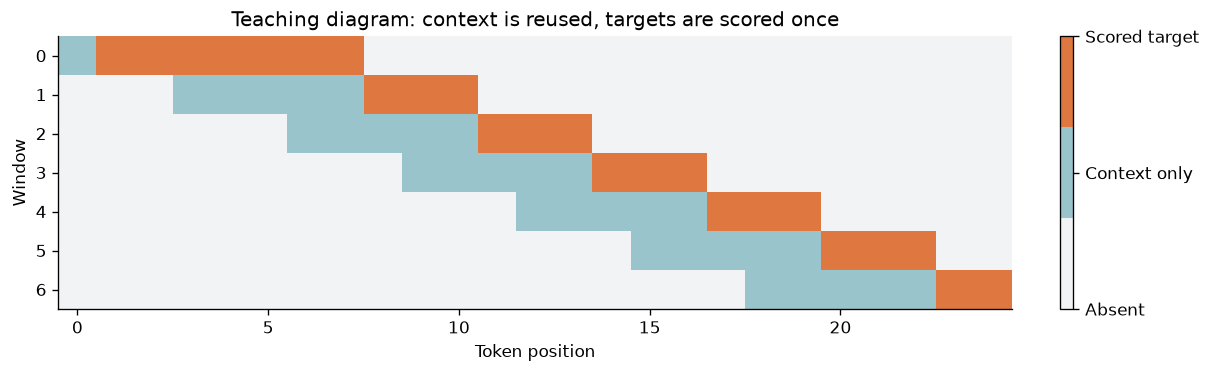

No calibration graph yet: prepare real data first.


In [7]:
window_grid = np.zeros((len(list(scoring_windows(25, 8, 3))), 25))
for row, (begin, end, first) in enumerate(scoring_windows(25, 8, 3)):
    window_grid[row, begin:end] = 1
    window_grid[row, first:end] = 2
from matplotlib.colors import ListedColormap
fig, axis = plt.subplots(figsize=(10, 3), layout='constrained')
image = axis.imshow(window_grid, aspect='auto', interpolation='nearest',
                    cmap=ListedColormap(['#f2f3f5', '#9ac4cb', '#df7740']), vmin=0, vmax=2)
axis.set(xlabel='Token position', ylabel='Window', title='Teaching diagram: context is reused, targets are scored once')
fig.colorbar(image, ax=axis, ticks=[0, 1, 2]).ax.set_yticklabels(['Absent', 'Context only', 'Scored target'])
fig.savefig(RESULTS / 'window_coverage.png')
plt.show()

if (RESULTS / 'prepared.json').exists():
    prepared = json.loads((RESULTS / 'prepared.json').read_text())
    data = prepared['data']
    fig, axes = plt.subplots(1, 2, figsize=(11, 3.5), layout='constrained')
    axes[0].hist([data['original_lengths'], data['lengths']], bins=25,
                 label=['Original', 'After truncation'], color=COLORS[:2])
    axes[0].set(xlabel='Tokens per calibration record', ylabel='Records', title='Calibration coverage')
    axes[0].legend()
    axes[1].bar(['Untruncated', 'Truncated'], [1 - data['truncated_fraction'], data['truncated_fraction']], color=COLORS[:2])
    axes[1].set(ylabel='Fraction of records', ylim=(0, 1), title='Truncation changes the data distribution')
    fig.savefig(RESULTS / 'calibration.png')
    plt.show()
    print('Samples:', len(data['sample_ids']), 'Calibration tokens:', data['calibration_tokens'],
          'Evaluation input tokens:', data['eval_input_tokens'])
else:
    print('No calibration graph yet: prepare real data first.')

## Local runtime: storage, responses and perplexity

Enable `RUN_LOCAL` after preparation. Each model runs in a **fresh subprocess**, sequentially; logs and metrics survive notebook interruption. Baseline labels come from checkpoint metadata and actual runtime dtype. The same reference tokenizer and saved evaluation tokens are used for every model. Warm-up and repeated sampling use matched seeds. Generated lengths and length-limit hits are recorded rather than assuming every response reaches the cap.

The timing is `output tokens / complete generate() duration`: **prefill plus decode**, excluding tokenizer work and model load. It is not isolated decode speed or time to first token. It is a Transformers experiment, not a vLLM serving result. Quantized kernels, memory bandwidth, output lengths and sampling can all change timing. Qualitative prompts show behavior but do not establish accuracy. In thinking mode change sampling to Qwen's recommended temperature 0.6 / top-p 0.95, increase the output budget, and keep that experiment separate. Default non-thinking uses temperature 0.7 / top-p 0.8 / top-k 20.

Storage bars distinguish weights from total checkpoint metadata and tokenizer files. Logical bytes follow symlinks; this is **not** physical disk usage of the shared Hugging Face cache. A 4-bit Linear layer is about four times smaller than a 16-bit layer, but embeddings, output head and scale metadata reduce whole-model compression.

Perplexity measures held-out next-token prediction. A 5% PPL rise is not a 5% accuracy drop. Compare only identical tokenization, context and preprocessing. Full-corpus PPL is reproducible for this protocol, not proof of coding or instruction-following quality. See [Hugging Face's sliding-window explanation](https://huggingface.co/docs/transformers/en/perplexity).

**Exercise:** predict whether longer prompts help or hurt the apparent tokens/s metric. Then compare identical workloads in vLLM rather than attributing every difference to the GPTQ algorithm.

In [21]:
if RUN_LOCAL:
    prepared = json.loads((RESULTS / 'prepared.json').read_text())
    order = list(prepared['models'])
    random.Random(CFG['seed']).shuffle(order)
    write_json(RESULTS / 'local_order.json', order)
    for name in order:
        launch_worker('local', {'name': name, 'model_path': prepared['models'][name]['path'],
                      'tokenizer_path': prepared['models']['reference']['path'], 'prompts': PROMPTS}, f'local-{name}')
else:
    print('Local GPU evaluation disabled.')

local_results = [json.loads(path.read_text()) for path in RESULTS.glob('local-*.json')
                 if not path.name.endswith(('.input.json', '.failure.json'))]
summary_rows, timing_rows = [], []
if (RESULTS / 'prepared.json').exists():
    prepared = json.loads((RESULTS / 'prepared.json').read_text())
    for result in local_results:
        name = result['model']
        info = prepared['models'][name]
        timings = pd.DataFrame(result['generation'])
        storage = 'quantized' if info['quantization'] else info['dtype']
        label = f"{name} ({storage} weights; {result['dtype']} runtime)"
        summary_rows.append({'model': name, 'label': label, 'weight_gib': info['weight_bytes'] / 2**30,
            'checkpoint_gib': info['total_bytes'] / 2**30, 'ppl': result['perplexity']['ppl'],
            'scored_tokens': result['perplexity']['scored_tokens'],
            'median_tokens_s': float(timings.tokens_per_second.median()),
            'p25_tokens_s': float(timings.tokens_per_second.quantile(.25)),
            'p75_tokens_s': float(timings.tokens_per_second.quantile(.75)),
            'peak_allocated_gib': float(timings.peak_allocated_gib.max()),
            'loaded_allocated_gib': result['loaded_memory']['allocated_gib']})
        timing_rows.extend({'model': name, **row} for row in result['generation'])
summary = pd.DataFrame(summary_rows)
timings = pd.DataFrame(timing_rows)
if not summary.empty:
    assert summary.scored_tokens.nunique() == 1
    assert len({result['perplexity']['eval_sha256'] for result in local_results}) == 1
    display(summary)
    display(timings[['model', 'prompt_id', 'repeat', 'output_tokens', 'seconds', 'hit_length_limit', 'response']])
    summary.to_csv(RESULTS / 'local_summary.csv', index=False)
    timings.to_csv(RESULTS / 'generation_samples.csv', index=False)
    fig, axes = plt.subplots(1, 4, figsize=(16, 4), layout='constrained')
    positions = np.arange(len(summary))
    axes[0].bar(positions - .18, summary.weight_gib, width=.36, label='Weights', color=COLORS[0])
    axes[0].bar(positions + .18, summary.checkpoint_gib, width=.36, label='Checkpoint', color=COLORS[1])
    axes[0].set_xticks(positions, summary.model)
    axes[0].set(title='Logical storage (lower better)', ylabel='GiB')
    axes[0].legend()
    axes[1].bar(summary.model, summary.median_tokens_s, color=COLORS[:len(summary)],
                yerr=[summary.median_tokens_s - summary.p25_tokens_s,
                      summary.p75_tokens_s - summary.median_tokens_s], capsize=4)
    axes[1].set(title='Transformers generation', ylabel='Tokens/s; median and IQR')
    axes[2].bar(summary.model, summary.peak_allocated_gib, color=COLORS[:len(summary)])
    axes[2].set(title='Generation peak allocated', ylabel='CUDA GiB (not system total)')
    axes[3].bar(summary.model, summary.ppl, color=COLORS[:len(summary)])
    axes[3].set(title='Held-out PPL (lower better)', ylabel='Perplexity')
    fig.suptitle(f'Local benchmark: {PROFILE} profile; same prompts and evaluation sequence')
    fig.savefig(RESULTS / 'local_dashboard.png')
    plt.show()
    fig, axis = plt.subplots(figsize=(9, 4), layout='constrained')
    grouped = list(timings.groupby(['model', 'prompt_id']))
    axis.boxplot([group.seconds for _, group in grouped], tick_labels=[f'{name}/P{prompt}' for (name, prompt), _ in grouped])
    axis.set(ylabel='Generate duration (seconds)', title='Timing distribution by model and prompt; not a confidence interval')
    fig.savefig(RESULTS / 'timing_distributions.png')
    plt.show()
else:
    print('No measured local results yet. Teaching diagrams are not benchmark data.')

Local GPU evaluation disabled.
No measured local results yet. Teaching diagrams are not benchmark data.


## Task accuracy: ask whether capabilities survived

Perplexity is only one lens. Use the [EleutherAI evaluation harness](https://github.com/EleutherAI/lm-evaluation-harness/blob/main/docs/interface.md) for HellaSwag, ARC-Challenge, GSM8K and IFEval. The first two use likelihood scoring; the others generate answers. Chat templates are applied only in the generative group here. Qwen thinking mode is explicitly recorded and must not be applied to likelihood scoring. The same tokenizer, task versions, few-shot counts, seeds, answer filters and output budgets are used for all checkpoints.

The notebook writes CLI commands, logs, task configurations and raw per-example results. The installed harness package is frozen before execution; inspect task configs/dataset hashes before publishing, because public dataset revisions can evolve. A smoke limit is for debugging answer extraction only. Final comparisons use the entire task split. Inspect samples for truncated reasoning and malformed final answers, not just a summary score.

A **paired bootstrap** resamples the same example IDs for both models, estimates the score difference, and reports a 95% interval. We match document and prompt hashes and refuse duplicate/mismatched examples. This interval reflects evaluation-sample uncertainty, not all hardware or training randomness. Repeating deterministic evaluation is not additional independent evidence. Multiple tasks introduce multiple comparisons: declare primary tasks beforehand; do not select only favorable results. An interval crossing the allowed loss is **inconclusive**, not a pass.

For your own lab data, add a held-out harness task in `CUSTOM_TASK_DIR` and append its name to the generative task group. Start with a frozen rubric and blinded human review where exact-match scoring is inadequate. The later custom-score importer supports paired, reviewed scores without pretending arbitrary text responses have objective accuracy.

In [17]:
CUSTOM_TASK_DIR = None
TASK_GROUPS = {'likelihood': ['hellaswag', 'arc_challenge'], 'generation': ['gsm8k', 'ifeval']}
TASK_METRICS = {'hellaswag': ('acc_norm', 'none'), 'arc_challenge': ('acc_norm', 'none'),
                'gsm8k': ('exact_match', 'strict-match'), 'ifeval': ('prompt_level_strict_acc', 'none')}
TASK_SEEDS = [CFG['seed']]


def run_logged(command, directory, stem, timeout=24 * 3600):
    directory = pathlib.Path(directory)
    directory.mkdir(parents=True, exist_ok=True)
    write_json(directory / f'{stem}.command.json', command)
    with (directory / f'{stem}.log').open('w') as log:
        try:
            subprocess.run(command, stdout=log, stderr=subprocess.STDOUT, check=True, timeout=timeout)
        except (subprocess.CalledProcessError, subprocess.TimeoutExpired, FileNotFoundError) as error:
            write_json(directory / f'{stem}.failure.json', {'error': str(error)})
            raise


def task_command(name, group, seed, prepared):
    model_args = {'pretrained': prepared['models'][name]['path'],
                  'tokenizer': prepared['models']['reference']['path'],
                  'dtype': 'bfloat16' if torch.cuda.is_bf16_supported() else 'float16'}
    if group == 'generation':
        model_args['enable_thinking'] = CFG['enable_thinking']
        if CFG['enable_thinking']:
            model_args['think_end_token'] = '</think>'
    command = [LM_EVAL_PYTHON, '-m', 'lm_eval', 'run', '--model', 'hf',
               '--model_args', ','.join(f'{key}={value}' for key, value in model_args.items()),
               '--tasks', ','.join(TASK_GROUPS[group]), '--batch_size', '1', '--device', 'cuda:0',
               '--seed', str(seed), '--num_fewshot', '0', '--log_samples', '--check_integrity',
               '--output_path', str(RESULTS / 'tasks' / name / group / str(seed))]
    if CFG['task_limit'] is not None:
        command += ['--limit', str(CFG['task_limit'])]
    if group == 'generation':
        command += ['--apply_chat_template', '--gen_kwargs',
                    f'do_sample=True,temperature={CFG["temperature"]},top_p={CFG["top_p"]},top_k={CFG["top_k"]},max_gen_toks={CFG["task_generation_tokens"]}']
    if CUSTOM_TASK_DIR:
        command += ['--include_path', str(CUSTOM_TASK_DIR)]
    return command


if RUN_TASKS:
    if not torch.cuda.is_available():
        raise RuntimeError('Task evaluation is configured for CUDA only.')
    prepared = json.loads((RESULTS / 'prepared.json').read_text())
    run_logged([LM_EVAL_PYTHON, '-m', 'lm_eval', 'run', '--help'], RESULTS, 'task_cli_help', timeout=120)
    run_logged([LM_EVAL_PYTHON, '-m', 'pip', 'freeze'], RESULTS, 'task_environment', timeout=60)
    write_json(RESULTS / 'task_plan.json', {'groups': TASK_GROUPS, 'metrics': TASK_METRICS,
               'seeds': TASK_SEEDS, 'generation_budget': CFG['task_generation_tokens'],
               'thinking': CFG['enable_thinking'], 'fewshot': 0})
    for seed in TASK_SEEDS:
        order = list(prepared['models'])
        random.Random(seed).shuffle(order)
        for name in order:
            for group in TASK_GROUPS:
                destination = RESULTS / 'tasks' / name / group / str(seed)
                if destination.exists():
                    raise FileExistsError(f'Existing task run: {destination}')
                command = task_command(name, group, seed, prepared)
                print(shlex.join(command))
                run_logged(command, destination, 'evaluation')
else:
    print('Task runs disabled. Missing lm_eval is not a zero accuracy score.')


def paired_interval(reference, candidate, seed=42, resamples=2000):
    reference = np.asarray(reference, dtype=float)
    candidate = np.asarray(candidate, dtype=float)
    if reference.ndim != 1 or reference.shape != candidate.shape or len(reference) < 2:
        raise ValueError('Need at least two matched examples.')
    if not np.isfinite(reference).all() or not np.isfinite(candidate).all():
        raise ValueError('Missing/non-finite scores cannot be silently removed.')
    if ((reference < 0) | (reference > 1) | (candidate < 0) | (candidate > 1)).any():
        raise ValueError('Scores must lie in [0, 1].')
    differences = 100 * (candidate - reference)
    rng = np.random.default_rng(seed)
    distribution = np.array([rng.choice(differences, size=len(differences), replace=True).mean()
                             for _ in range(resamples)])
    lower, upper = np.quantile(distribution, [.025, .975])
    return {'difference_pp': float(differences.mean()), 'low_pp': float(lower), 'high_pp': float(upper),
            'examples': len(reference)}


def interval_decision(low, high, margin):
    if low >= -margin:
        return 'pass'
    if high < -margin:
        return 'fail'
    return 'inconclusive'


identical = paired_interval([0, 1, 1], [0, 1, 1])
assert identical['low_pp'] == identical['high_pp'] == 0
assert interval_decision(-2, 0, 1) == 'inconclusive'
assert interval_decision(-.5, .5, 1) == 'pass'
assert interval_decision(-3, -2, 1) == 'fail'
print('PASS: paired bootstrap identity and non-inferiority decision boundaries.')

Task runs disabled. Missing lm_eval is not a zero accuracy score.
PASS: paired bootstrap identity and non-inferiority decision boundaries.


In [11]:
def sample_index(records, metric, filter_name):
    indexed = {}
    for record in records:
        if record.get('filter', 'none') != filter_name:
            continue
        key = str(record['doc_id'])
        if key in indexed:
            raise ValueError(f'Duplicate example {key}; do not pool seeds as independent examples.')
        indexed[key] = (tuple(record[field] for field in ('doc_hash', 'prompt_hash', 'target_hash')),
                        float(record[metric]))
    if not indexed:
        raise ValueError(f'No samples for {metric}/{filter_name}; inspect the harness schema.')
    return indexed


def compare_samples(reference, candidate, metric, filter_name):
    reference = sample_index(reference, metric, filter_name)
    candidate = sample_index(candidate, metric, filter_name)
    if reference.keys() != candidate.keys():
        raise ValueError('Different example IDs; an inner join would hide missing results.')
    keys = sorted(reference)
    if any(reference[key][0] != candidate[key][0] for key in keys):
        raise ValueError('Document/prompt/target hash mismatch.')
    interval = paired_interval([reference[key][1] for key in keys], [candidate[key][1] for key in keys])
    return {**interval, 'reference_score': np.mean([reference[key][1] for key in keys]).item(),
            'candidate_score': np.mean([candidate[key][1] for key in keys]).item()}


def task_samples(model, task, seed):
    paths = list((RESULTS / 'tasks' / model).glob(f'*/{seed}/**/samples_{task}_*.jsonl'))
    if len(paths) != 1:
        raise ValueError(f'Expected one sample file for {model}/{task}/{seed}, found {len(paths)}.')
    return [json.loads(line) for line in paths[0].read_text().splitlines() if line.strip()]


fixture = [{'doc_id': position, 'doc_hash': str(position), 'prompt_hash': 'prompt', 'target_hash': 'target',
            'acc': score, 'filter': 'none'} for position, score in enumerate([0, 1, 1])]
assert compare_samples(fixture, list(reversed(fixture)), 'acc', 'none')['difference_pp'] == 0
try:
    compare_samples(fixture, fixture[:-1], 'acc', 'none')
except ValueError:
    pass
else:
    raise AssertionError('Missing examples must be rejected.')
print('PASS: sample alignment, reordering and missing-example rejection.')

quality_rows = []
if (RESULTS / 'tasks').exists():
    for name in MODELS:
        if name == 'reference':
            continue
        for task, (metric, filter_name) in TASK_METRICS.items():
            for seed in TASK_SEEDS:
                try:
                    interval = compare_samples(task_samples('reference', task, seed), task_samples(name, task, seed), metric, filter_name)
                    decision = interval_decision(interval['low_pp'], interval['high_pp'], CFG['max_accuracy_drop_pp'])
                    quality_rows.append({'model': name, 'task': task, 'seed': seed, **interval,
                                         'decision': decision if PROFILE == 'full' else 'inconclusive'})
                except (ValueError, KeyError) as error:
                    quality_rows.append({'model': name, 'task': task, 'seed': seed,
                                         'decision': 'inconclusive', 'error': str(error)})
quality = pd.DataFrame(quality_rows)
if not quality.empty:
    display(quality)
    quality.to_csv(RESULTS / 'task_comparisons.csv', index=False)
    plotted = quality.dropna(subset=['difference_pp']) if 'difference_pp' in quality else pd.DataFrame()
    if not plotted.empty:
        fig, axis = plt.subplots(figsize=(9, 4), layout='constrained')
        positions = np.arange(len(plotted))
        axis.hlines(positions, plotted.low_pp, plotted.high_pp, color=COLORS[0], linewidth=3)
        axis.scatter(plotted.difference_pp, positions, color=COLORS[1])
        axis.axvline(-CFG['max_accuracy_drop_pp'], linestyle='--', color=COLORS[3], label='Allowed loss')
        axis.axvline(0, color='gray', linewidth=1)
        axis.set_yticks(positions, plotted.model + '/' + plotted.task + '/seed' + plotted.seed.astype(str))
        axis.set(xlabel='Candidate minus reference (percentage points)', title='Paired 95% bootstrap intervals; higher is better')
        axis.legend()
        fig.savefig(RESULTS / 'task_intervals.png')
        plt.show()
else:
    print('No task samples yet. Never infer task accuracy from perplexity alone.')

PASS: sample alignment, reordering and missing-example rejection.
No task samples yet. Never infer task accuracy from perplexity alone.


## Serving: throughput is useful only at acceptable latency

Use [vLLM's benchmark client](https://docs.vllm.ai/en/stable/cli/bench/serve/) instead of writing a streaming load generator. It records request errors, token counts and streaming timestamps. This notebook manages only servers it launches, on loopback and an available port, and tears them down on failure or interruption. Each case/repetition gets a fresh server. Model download is excluded, but server readiness includes loading/compilation; filesystem and compilation caches can remain warm. Do not call this a machine-cold boot measurement.

| Measurement | Interpretation |
|---|---|
| TTFT | Client send to first returned token; includes server queue and prefill |
| TPOT | $(\mathrm{E2EL}-\mathrm{TTFT})/(N_{out}-1)$ for outputs longer than one token |
| ITL | Gap between streamed chunks/tokens; chunking can affect interpretation |
| E2EL | Complete request latency |
| Throughput | Successful output tokens divided by measured wall time |
| Goodput | Successful requests meeting **both** latency limits per second |

Capped-concurrency tests use an infinite offered rate and concurrency 1, 4, 16, 32. Open-loop tests use finite Poisson arrival rates with **no client concurrency cap**. Adjust the preregistered rate grid after a separate pilot, then create a new run. A finite run is not proof of indefinite queue stability. Check offered versus achieved rates, timeouts, failures and server logs.

The four fixed-length input/output regimes are 128/128, 1024/256, 4096/256 and 1024/1024 tokens. Synthetic tests force output length and measure runtime capacity, not response quality. Prefix-cache tests hold total input length fixed and compare the **same shared-prefix workload** with caching off/on. Their warmed prefix intentionally differs from uncached requests. Natural-EOS tests require your representative custom dataset; they are not replaced with random text. Set `CUSTOM_SERVING_DATA` to a file in the installed vLLM custom-dataset format and validate a smoke run first. Full results are not deployment-ready without representative traffic.

On GB10, system and GPU memory share a physical pool. Never add CUDA allocation and process RSS as if they were independent. We save system-available memory, server-tree RSS, raw `nvidia-smi` samples and server metrics separately. Sampling can miss peaks; unsupported counters stay missing. vLLM reserves KV capacity, so equal utilization settings may reserve similar totals even when weight sizes differ. Keep dtype, KV dtype, tensor parallelism, context, scheduler and memory utilization fixed; inspect logs for the actual selected quantization kernel.

A full matrix can take hours. All serving remains opt-in. Tail percentiles from eight smoke requests are diagnostic, not reliable p99 estimates. Repeat runs, show individual observations, and use the worst repetition for SLO checks rather than hiding poor runs in an average.

In [12]:
import socket
import signal
import threading
import urllib.request
import urllib.error
from contextlib import contextmanager

CUSTOM_SERVING_DATA = None
ARRIVAL_RATES = [0.5, 1.0, 2.0]
CONCURRENCIES = [1, 4] if PROFILE == 'smoke' else [1, 4, 16, 32]
REGIMES = [(128, 128)] if PROFILE == 'smoke' else [(128, 128), (1024, 256), (4096, 256), (1024, 1024)]
SERVER_SETTINGS = {'max_model_len': 8192, 'gpu_memory_utilization': .7,
                   'tensor_parallel_size': 1, 'max_num_seqs': 64, 'max_num_batched_tokens': 8192,
                   'kv_cache_dtype': 'auto', 'startup_timeout': 1200, 'benchmark_timeout': 7200}
VLLM_COMMAND = [VLLM_PYTHON, '-m', 'vllm.entrypoints.cli.main']


def serving_cases():
    cases = []
    for input_len, output_len in REGIMES:
        for concurrency in CONCURRENCIES:
            cases.append({'kind': 'concurrency', 'input': input_len, 'output': output_len,
                          'concurrency': concurrency, 'rate': 'inf', 'prefix': 0, 'cache': False})
        for rate in ARRIVAL_RATES:
            cases.append({'kind': 'arrival', 'input': input_len, 'output': output_len,
                          'concurrency': None, 'rate': rate, 'prefix': 0, 'cache': False})
    if PROFILE == 'full':
        for cache in (False, True):
            cases.append({'kind': 'prefix', 'input': 1024, 'output': 256, 'concurrency': 4,
                          'rate': 'inf', 'prefix': 512, 'cache': cache})
    if CUSTOM_SERVING_DATA:
        for rate in ARRIVAL_RATES:
            cases.append({'kind': 'natural', 'input': None, 'output': CFG['generation_tokens'],
                          'concurrency': None, 'rate': rate, 'prefix': 0, 'cache': False})
    return cases


def bench_command(case, port, model_path, tokenizer_path, directory, seed):
    command = VLLM_COMMAND + ['bench', 'serve', '--base-url', f'http://127.0.0.1:{port}',
        '--model', model_path, '--served-model-name', 'benchmark-lab', '--tokenizer', tokenizer_path,
        '--num-prompts', str(CFG['requests']), '--seed', str(seed), '--request-rate', str(case['rate']),
        '--burstiness', '1', '--num-warmups', str(CFG['warmups']), '--save-result', '--save-detailed',
        '--result-dir', str(directory), '--result-filename', 'raw.json',
        '--percentile-metrics', 'ttft,tpot,itl,e2el', '--metric-percentiles', '50,95,99',
        '--goodput', f'ttft:{CFG["ttft_ms"]}', f'tpot:{CFG["tpot_ms"]}',
        '--temperature', str(CFG['temperature']), '--top-p', str(CFG['top_p']), '--top-k', str(CFG['top_k']),
        '--extra-body', json.dumps({'seed': seed, 'chat_template_kwargs': {'enable_thinking': CFG['enable_thinking']}})]
    if case['concurrency'] is not None:
        command += ['--max-concurrency', str(case['concurrency'])]
    if case['kind'] == 'natural':
        command += ['--backend', 'openai-chat', '--endpoint', '/v1/chat/completions',
                    '--dataset-name', 'custom', '--dataset-path', str(CUSTOM_SERVING_DATA),
                    '--skip-chat-template', '--custom-output-len', str(case['output'])]
    else:
        command += ['--backend', 'openai', '--endpoint', '/v1/completions', '--dataset-name', 'random',
                    '--random-input-len', str(case['input'] - case['prefix']),
                    '--random-prefix-len', str(case['prefix']), '--random-output-len', str(case['output']),
                    '--random-range-ratio', '0', '--ignore-eos']
    return command


def require_flags(command, help_text):
    missing = [argument for argument in command if argument.startswith('--') and argument not in help_text]
    if missing:
        raise RuntimeError(f'Installed CLI does not document required flags: {missing}')


def stop_owned_process(process):
    try:
        os.killpg(process.pid, signal.SIGTERM)
    except ProcessLookupError:
        pass
    try:
        process.wait(timeout=30)
    except subprocess.TimeoutExpired:
        os.killpg(process.pid, signal.SIGKILL)
        process.wait(timeout=30)


def sample_server_memory(process, stop, destination):
    with destination.open('w') as stream:
        while not stop.is_set():
            record = {'time': time.time(), 'system_available_gib': psutil.virtual_memory().available / 2**30}
            try:
                parent = psutil.Process(process.pid)
                record['server_tree_rss_gib'] = sum(item.memory_info().rss for item in [parent, *parent.children(recursive=True)]) / 2**30
            except (psutil.NoSuchProcess, psutil.AccessDenied):
                record['server_tree_rss_gib'] = None
            if shutil.which('nvidia-smi'):
                try:
                    measured = subprocess.run(['nvidia-smi', '--query-gpu=timestamp,memory.used,utilization.gpu,power.draw,temperature.gpu',
                                              '--format=csv,noheader,nounits'], capture_output=True, text=True, timeout=5)
                    record['nvidia_smi_raw'] = measured.stdout.strip() if measured.returncode == 0 else None
                except subprocess.TimeoutExpired:
                    record['nvidia_smi_raw'] = None
            stream.write(json.dumps(record) + '\n')
            stream.flush()
            stop.wait(1)


@contextmanager
def owned_server(model_path, tokenizer_path, case, directory, server_help):
    with socket.socket() as candidate:
        candidate.bind(('127.0.0.1', 0))
        port = candidate.getsockname()[1]
    command = VLLM_COMMAND + ['serve', model_path, '--host', '127.0.0.1', '--port', str(port),
        '--served-model-name', 'benchmark-lab', '--tokenizer', tokenizer_path,
        '--dtype', 'bfloat16' if torch.cuda.is_bf16_supported() else 'float16',
        '--max-model-len', str(SERVER_SETTINGS['max_model_len']),
        '--gpu-memory-utilization', str(SERVER_SETTINGS['gpu_memory_utilization']),
        '--tensor-parallel-size', str(SERVER_SETTINGS['tensor_parallel_size']),
        '--max-num-seqs', str(SERVER_SETTINGS['max_num_seqs']),
        '--max-num-batched-tokens', str(SERVER_SETTINGS['max_num_batched_tokens']),
        '--kv-cache-dtype', SERVER_SETTINGS['kv_cache_dtype'], '--generation-config', 'vllm',
        '--seed', str(CFG['seed']), '--enable-prefix-caching' if case['cache'] else '--no-enable-prefix-caching']
    require_flags(command, server_help)
    write_json(directory / 'server.command.json', command)
    stop = threading.Event()
    with (directory / 'server.log').open('w') as log:
        started = time.perf_counter()
        process = subprocess.Popen(command, stdout=log, stderr=subprocess.STDOUT, start_new_session=True)
        monitor = threading.Thread(target=sample_server_memory, args=(process, stop, directory / 'memory.jsonl'), daemon=True)
        monitor.start()
        try:
            opener = urllib.request.build_opener(urllib.request.ProxyHandler({}))
            deadline = time.monotonic() + SERVER_SETTINGS['startup_timeout']
            while True:
                if process.poll() is not None:
                    raise RuntimeError(f'Server exited ({process.returncode}); inspect server.log.')
                if time.monotonic() > deadline:
                    raise TimeoutError('Server readiness timed out.')
                try:
                    with opener.open(f'http://127.0.0.1:{port}/v1/models', timeout=2) as response:
                        models = json.load(response)['data']
                    if any(model['id'] == 'benchmark-lab' and model.get('root') == model_path for model in models):
                        break
                except (OSError, ValueError, KeyError):
                    pass
                stop.wait(.5)
            write_json(directory / 'startup.json', {'seconds': time.perf_counter() - started, 'pid': process.pid, 'port': port})
            yield port
            try:
                with opener.open(f'http://127.0.0.1:{port}/metrics', timeout=5) as response:
                    (directory / 'metrics.txt').write_bytes(response.read())
            except OSError as error:
                (directory / 'metrics_unavailable.txt').write_text(str(error))
        finally:
            stop.set()
            stop_owned_process(process)
            monitor.join(timeout=10)


CASES = serving_cases()
for case in CASES:
    command = bench_command(case, 12345, '/model', '/tokenizer', '/results', 42)
    assert ('--max-concurrency' in command) == (case['concurrency'] is not None)
    assert ('--ignore-eos' in command) == (case['kind'] != 'natural')
    if case['input']:
        assert case['input'] + case['output'] <= SERVER_SETTINGS['max_model_len']
print(f'PASS: serving command invariants. Planned cases per model: {len(CASES)} x {CFG["repetitions"]} repetitions.')
print(shlex.join(bench_command(CASES[0], 12345, '/model', '/tokenizer', '/results', CFG['seed'])))

PASS: serving command invariants. Planned cases per model: 5 x 2 repetitions.
/home/nizare/InferenceOptimizer/.venv/bin/python -m vllm.entrypoints.cli.main bench serve --base-url http://127.0.0.1:12345 --model /model --served-model-name benchmark-lab --tokenizer /tokenizer --num-prompts 8 --seed 42 --request-rate inf --burstiness 1 --num-warmups 2 --save-result --save-detailed --result-dir /results --result-filename raw.json --percentile-metrics ttft,tpot,itl,e2el --metric-percentiles 50,95,99 --goodput ttft:2000 tpot:100 --temperature 0.7 --top-p 0.8 --top-k 20 --extra-body '{"seed": 42, "chat_template_kwargs": {"enable_thinking": false}}' --max-concurrency 1 --backend openai --endpoint /v1/completions --dataset-name random --random-input-len 128 --random-prefix-len 0 --random-output-len 128 --random-range-ratio 0 --ignore-eos


In [13]:
def summarize_serving(raw, case):
    required = ['duration', 'completed', 'num_prompts', 'ttfts', 'latencies', 'output_lens', 'errors']
    if any(key not in raw for key in required):
        raise ValueError('Detailed vLLM schema missing; inspect raw.json and installed CLI version.')
    count = int(raw['num_prompts'])
    if count < 1 or raw['duration'] <= 0:
        raise ValueError('Invalid request count/duration.')
    if any(len(raw[key]) != count for key in ('ttfts', 'latencies', 'output_lens', 'errors')):
        raise ValueError('Truncated per-request arrays.')
    success = np.array([not bool(error) for error in raw['errors']])
    if int(success.sum()) != int(raw['completed']):
        raise ValueError('Request success mask disagrees with completed count.')
    ttft = np.asarray(raw['ttfts'], dtype=float)[success] * 1000
    latency = np.asarray(raw['latencies'], dtype=float)[success] * 1000
    lengths = np.asarray(raw['output_lens'], dtype=int)[success]
    if not np.isfinite(ttft).all() or not np.isfinite(latency).all() or (ttft < 0).any() or (latency < ttft).any():
        raise ValueError('Invalid successful-request timings.')
    tpot = np.divide(latency - ttft, lengths - 1, out=np.zeros_like(latency), where=lengths > 1)
    good = (ttft <= CFG['ttft_ms']) & (tpot <= CFG['tpot_ms']) & (lengths > 0)
    if case['kind'] != 'natural' and (lengths != case['output']).any():
        raise ValueError('Fixed-output benchmark did not return the requested token count.')
    row = {'completed': int(success.sum()), 'failed': count - int(success.sum()),
           'failure_fraction': float(1 - success.mean()), 'goodput_fraction': float(good.sum() / count),
           'goodput_rps': float(good.sum() / raw['duration']),
           'request_rps': float(success.sum() / raw['duration']),
           'output_tokens_s': float(lengths.sum() / raw['duration']), 'duration': raw['duration'],
           'length_cap_fraction': float(np.mean(lengths >= case['output'])) if len(lengths) else None}
    for metric, values in [('ttft', ttft), ('tpot', tpot[lengths > 1]), ('e2el', latency)]:
        for percentile in (50, 95, 99):
            row[f'p{percentile}_{metric}_ms'] = float(np.percentile(values, percentile)) if len(values) else None
    row['slo_pass'] = bool(len(ttft) and row['goodput_fraction'] >= CFG['min_goodput_fraction']
                           and row['failure_fraction'] <= CFG['max_failure_fraction'])
    return row


synthetic_raw = {'duration': 2, 'completed': 2, 'num_prompts': 3,
                 'ttfts': [.1, 3., 0], 'latencies': [.2, 3.1, 0], 'output_lens': [2, 2, 0], 'errors': ['', '', 'timeout']}
tested = summarize_serving(synthetic_raw, {'kind': 'concurrency', 'output': 2})
assert tested['failed'] == 1 and tested['goodput_fraction'] == 1 / 3 and tested['goodput_rps'] == .5
assert not tested['slo_pass']
print('PASS: failed requests and latency violations reduce goodput. Test fixture is not saved as a benchmark.')

if RUN_SERVING:
    prepared = json.loads((RESULTS / 'prepared.json').read_text())
    bench_help = subprocess.run(VLLM_COMMAND + ['bench', 'serve', '--help'], capture_output=True, text=True, check=True, timeout=120).stdout
    server_help = subprocess.run(VLLM_COMMAND + ['serve', '--help=all'], capture_output=True, text=True, check=True, timeout=120).stdout
    (RESULTS / 'vllm_bench_help.txt').write_text(bench_help)
    (RESULTS / 'vllm_server_help.txt').write_text(server_help)
    run_logged([VLLM_PYTHON, '-m', 'pip', 'freeze'], RESULTS, 'vllm_environment', timeout=60)
    write_json(RESULTS / 'serving_plan.json', {'cases': CASES, 'server': SERVER_SETTINGS, 'repetitions': CFG['repetitions'],
               'custom_data_sha256': file_hash(CUSTOM_SERVING_DATA) if CUSTOM_SERVING_DATA else None})
    jobs = [(name, repetition, index, case) for name in prepared['models']
            for repetition in range(CFG['repetitions']) for index, case in enumerate(CASES)]
    random.Random(CFG['seed']).shuffle(jobs)
    write_json(RESULTS / 'serving_order.json', [[name, repetition, index] for name, repetition, index, _ in jobs])
    for name, repetition, index, case in jobs:
        directory = RESULTS / 'serving' / f'{name}-r{repetition}-c{index}'
        directory.mkdir(parents=True, exist_ok=False)
        identity = {'model': name, 'repeat': repetition, 'case_id': index, **case}
        write_json(directory / 'case.json', identity)
        try:
            model_path = prepared['models'][name]['path']
            tokenizer_path = prepared['models']['reference']['path']
            with owned_server(model_path, tokenizer_path, case, directory, server_help) as port:
                command = bench_command(case, port, model_path, tokenizer_path, directory, CFG['seed'] + repetition)
                require_flags(command, bench_help)
                run_logged(command, directory, 'client', timeout=SERVER_SETTINGS['benchmark_timeout'])
                raw = json.loads((directory / 'raw.json').read_text())
                measured = summarize_serving(raw, case)
                if raw['num_prompts'] != CFG['requests']:
                    raise ValueError('Actual request count differs from the registered plan.')
            write_json(directory / 'summary.json', {**identity, **measured})
        except Exception as error:
            write_json(directory / 'failure.json', {**identity, 'error': str(error), 'decision': 'inconclusive'})
            print(f'{name}/r{repetition}/c{index} failed; inspect {directory}')
else:
    print('Serving disabled. No server was launched.')

serving = pd.DataFrame([json.loads(path.read_text()) for path in (RESULTS / 'serving').glob('*/summary.json')])
serving_failures = [json.loads(path.read_text()) for path in (RESULTS / 'serving').glob('*/failure.json')]
if not serving.empty:
    serving.to_csv(RESULTS / 'serving_summary.csv', index=False)
    display(serving)
if serving_failures:
    display(pd.DataFrame(serving_failures))

PASS: failed requests and latency violations reduce goodput. Test fixture is not saved as a benchmark.
Serving disabled. No server was launched.


In [14]:
def plot_serving(frame):
    if frame.empty:
        print('Serving charts await measured results.')
        return
    for kind, horizontal in [('concurrency', 'concurrency'), ('arrival', 'rate'), ('natural', 'rate')]:
        selected = frame.loc[frame.kind == kind]
        if selected.empty:
            continue
        fig, axes = plt.subplots(2, 2, figsize=(12, 8), layout='constrained')
        metrics = [('output_tokens_s', 'Output tokens/s'), ('p95_ttft_ms', 'P95 TTFT (ms)'),
                   ('p95_tpot_ms', 'P95 TPOT (ms)'), ('goodput_fraction', 'SLO-good / all offered requests')]
        for (name, input_len, output_len), group in selected.groupby(['model', 'input', 'output'], dropna=False):
            label = f'{name} {input_len}/{output_len}'
            for axis, (metric, title) in zip(axes.flat, metrics):
                axis.scatter(group[horizontal].astype(float), group[metric], alpha=.3, s=18)
                medians = group.groupby(horizontal)[metric].median().sort_index()
                axis.plot(medians.index.astype(float), medians.values, marker='o', label=label)
                axis.set(xlabel='Concurrency cap' if horizontal == 'concurrency' else 'Offered requests/s', ylabel=title)
        axes[0, 1].axhline(CFG['ttft_ms'], linestyle='--', color=COLORS[3])
        axes[1, 0].axhline(CFG['tpot_ms'], linestyle='--', color=COLORS[3])
        axes[1, 1].axhline(CFG['min_goodput_fraction'], linestyle='--', color=COLORS[3])
        axes[0, 0].legend(fontsize=8)
        fig.suptitle(f'{kind}: points are runs, lines are medians; {PROFILE} profile')
        fig.savefig(RESULTS / f'serving_{kind}.png')
        plt.show()
    capacity = []
    capped = frame.loc[frame.kind == 'concurrency']
    for (name, input_len, output_len), group in capped.groupby(['model', 'input', 'output']):
        passes = group.groupby('concurrency').agg(all_pass=('slo_pass', 'all'), repetitions=('repeat', 'nunique'))
        valid = passes.loc[passes.all_pass & (passes.repetitions == CFG['repetitions'])]
        capacity.append({'model': name, 'input': input_len, 'output': output_len,
                         'largest_tested_passing_cap': None if valid.empty else int(valid.index.max())})
    if capacity:
        capacity_frame = pd.DataFrame(capacity)
        display(capacity_frame)
        capacity_frame.to_csv(RESULTS / 'tested_capacity.csv', index=False)
    first_case = int(frame.case_id.min())
    fig, axes = plt.subplots(1, 2, figsize=(11, 4), layout='constrained')
    for path in sorted((RESULTS / 'serving').glob('*/summary.json')):
        record = json.loads(path.read_text())
        if record['case_id'] != first_case or record['repeat'] != 0:
            continue
        raw = json.loads((path.parent / 'raw.json').read_text())
        values = np.sort([value * 1000 for value, error in zip(raw['ttfts'], raw['errors']) if not error])
        if len(values):
            axes[0].step(values, np.arange(1, len(values) + 1) / len(values), label=record['model'])
        memory_file = path.parent / 'memory.jsonl'
        if memory_file.exists():
            samples = pd.DataFrame([json.loads(line) for line in memory_file.read_text().splitlines()])
            if not samples.empty:
                axes[1].plot(samples.time - samples.time.iloc[0], samples.system_available_gib, label=record['model'])
    axes[0].set(xlabel='TTFT (ms)', ylabel='Cumulative fraction', title=f'Successful requests only; case {first_case}, repeat 0')
    axes[1].set(xlabel='Seconds from launch', ylabel='System available GiB', title='Sampled headroom; includes startup')
    for axis in axes:
        if axis.lines:
            axis.legend()
    fig.savefig(RESULTS / 'serving_distributions_memory.png')
    plt.show()


plot_serving(serving)

Serving charts await measured results.


## Controlled sweep: calibration size and group size

Change one factor at a time: compare 128 versus 256 calibration examples at group size 128, then group size 128 versus 64 at 256 examples. Smaller groups add scale metadata and may improve reconstruction, but can change kernel efficiency. More calibration data costs time and is not guaranteed to improve every task.

Each candidate starts from the original floating-point checkpoint in a new process. Calibration subsets are nested, seeded training records. **Recipe selection uses WikiText validation, not test.** The sweep is exploratory: choose a candidate, freeze its artifact hash, then evaluate it once on the untouched test set and task suite in a new experiment. Do not pick a winner by repeatedly looking at final test scores.

A Pareto point is not dominated simultaneously in storage, validation perplexity and measured local generation speed. The frontier below uses point estimates, not a claim of statistical superiority. Small timing differences can be noise. A Transformers frontier is not a vLLM serving frontier. AWQ checkpoints can join the main comparison through `AWQ_PATH`, but GPTQ calibration sweeps do not train AWQ.

In [15]:
WORKER_DEFINITIONS = True
SWEEP = [(128, 128), (256, 128), (256, 64)]


def validation_data_job(payload):
    from datasets import load_dataset
    prepared = json.loads((pathlib.Path(payload['out']) / 'prepared.json').read_text())
    settings = payload['settings']
    destination = pathlib.Path(payload['destination'])
    destination.mkdir(parents=True, exist_ok=False)
    tokenizer = AutoTokenizer.from_pretrained(prepared['models']['reference']['path'], local_files_only=True)
    dataset = load_dataset(settings['dataset'], settings['dataset_config'], split='validation',
                           revision=prepared['data']['dataset_revision'], cache_dir=str(pathlib.Path(settings['cache']) / 'datasets'))
    text = '\n\n'.join(dataset['text'])
    tokens = tokenizer(text, add_special_tokens=False, truncation=False)['input_ids']
    if settings['max_eval_tokens'] is not None:
        tokens = tokens[:settings['max_eval_tokens']]
    np.save(destination / 'eval_tokens.npy', np.asarray(tokens, dtype=np.int64))
    return {'split': 'validation', 'dataset_revision': prepared['data']['dataset_revision'],
            'tokens': len(tokens), 'sha256': file_hash(destination / 'eval_tokens.npy')}


def pareto_mask(costs):
    costs = np.asarray(costs, dtype=float)
    if costs.ndim != 2 or not np.isfinite(costs).all():
        raise ValueError('Finite two-dimensional costs required; all columns minimized.')
    return np.array([not np.any(np.all(costs <= point, axis=1) & np.any(costs < point, axis=1)) for point in costs])


assert pareto_mask([[1, 2], [2, 1], [3, 3]]).tolist() == [True, True, False]
assert len(SWEEP) <= 3
if RUN_SWEEP:
    prepared = json.loads((RESULTS / 'prepared.json').read_text())
    validation_dir = RESULTS / 'sweep_validation'
    launch_worker('validation_data', {'destination': str(validation_dir)}, 'sweep-data')
    reference = launch_worker('local', {'out': str(validation_dir), 'name': 'reference',
        'model_path': prepared['models']['reference']['path'], 'tokenizer_path': prepared['models']['reference']['path'],
        'prompts': PROMPTS}, 'sweep-local-reference')
    for sample_count, group_size in SWEEP:
        settings = {**CFG, 'calibration_samples': sample_count, 'group_size': group_size}
        name = f'n{sample_count}-g{group_size}'
        destination = RESULTS / 'sweep_models' / name
        launch_worker('quantize', {'settings': settings, 'destination': str(destination)}, f'sweep-quantize-{name}')
        launch_worker('local', {'settings': settings, 'out': str(validation_dir), 'name': name,
            'model_path': str(destination), 'tokenizer_path': prepared['models']['reference']['path'],
            'prompts': PROMPTS}, f'sweep-local-{name}')
else:
    print('Quantization sweep disabled; original checkpoint remains unchanged.')

sweep_rows = []
for path in RESULTS.glob('sweep-local-*.json'):
    if path.name.endswith(('.input.json', '.failure.json')):
        continue
    measured = json.loads(path.read_text())
    name = measured['model']
    if name == 'reference':
        model_path = json.loads((RESULTS / 'prepared.json').read_text())['models']['reference']['path']
    else:
        model_path = RESULTS / 'sweep_models' / name
    info = validate_checkpoint(model_path)
    sweep_rows.append({'model': name, 'weight_gib': info['weight_bytes'] / 2**30,
                       'validation_ppl': measured['perplexity']['ppl'],
                       'tokens_s': float(np.median([row['tokens_per_second'] for row in measured['generation']]))})
sweep = pd.DataFrame(sweep_rows)
if not sweep.empty:
    sweep['pareto'] = pareto_mask(sweep[['weight_gib', 'validation_ppl', 'tokens_s']].to_numpy() * [1, 1, -1])
    display(sweep)
    sweep.to_csv(RESULTS / 'sweep_validation_summary.csv', index=False)
    fig, axis = plt.subplots(figsize=(8, 5), layout='constrained')
    points = axis.scatter(sweep.weight_gib, sweep.validation_ppl, c=sweep.tokens_s, cmap='viridis', s=90)
    frontier = sweep.loc[sweep.pareto]
    axis.scatter(frontier.weight_gib, frontier.validation_ppl, facecolors='none', edgecolors='black', s=160, label='Pareto point estimate')
    for row in sweep.itertuples():
        axis.annotate(row.model, (row.weight_gib, row.validation_ppl), xytext=(5, 5), textcoords='offset points')
    fig.colorbar(points, ax=axis, label='Median local generation tokens/s')
    axis.set(xlabel='Weights GiB (lower better)', ylabel='Validation PPL (lower better)', title='Exploratory recipe frontier; not final test results')
    axis.legend()
    fig.savefig(RESULTS / 'sweep_frontier.png')
    plt.show()
print('PASS: Pareto dominance test.')

Quantization sweep disabled; original checkpoint remains unchanged.
PASS: Pareto dominance test.


## Optional private scores and energy accounting

For a private evaluation, freeze the prompts, targets and rubric before reading model outputs. Score blind to model identity and review disagreements. Supply a CSV with `model,doc_id,doc_hash,prompt_hash,target_hash,score`; scores must be in [0,1]. Hashes identify identical evaluation content, not just coincidentally matching row numbers. The importer will not silently drop missing examples. Keep private prompts/responses out of public commits.

Energy is optional because many systems do not expose a reliable total-system power counter. If you have synchronized wall-meter samples spanning the **same steady-state interval** as the token count, integrate them using the helper below:

$$E_{J}=\int P_W(t)\,dt,\qquad E_{\text{token}}=E_J/N_{\text{successful output tokens}}.$$

Do not use GPU TDP as measured energy, and do not label GPU-only power as whole-system energy. Report whether idle power was subtracted. For cost, divide actual run cost by the count of successful requests meeting the quality/latency gate. A locally chosen protocol is inspired by [MLPerf's quality and performance discipline](https://mlcommons.org/benchmarks/inference-datacenter/), not an official MLPerf submission.

In [18]:
CUSTOM_SCORES_CSV = None
CUSTOM_RUBRIC_ID = None
private_quality = pd.DataFrame()
if CUSTOM_SCORES_CSV:
    if not CUSTOM_RUBRIC_ID:
        raise ValueError('Record a frozen rubric identifier or hash.')
    scored = pd.read_csv(CUSTOM_SCORES_CSV, dtype={'doc_id': str})
    required = {'model', 'doc_id', 'doc_hash', 'prompt_hash', 'target_hash', 'score'}
    if not required.issubset(scored.columns) or scored[list(required)].isna().any().any():
        raise ValueError('Private scores require all columns with no missing values.')
    baseline = scored.loc[scored.model == 'reference'].to_dict('records')
    private_rows = []
    for name in scored.model.unique():
        if name == 'reference':
            continue
        compared = compare_samples(baseline, scored.loc[scored.model == name].to_dict('records'), 'score', 'none')
        decision = interval_decision(compared['low_pp'], compared['high_pp'], CFG['max_accuracy_drop_pp'])
        private_rows.append({'model': name, **compared, 'decision': decision if PROFILE == 'full' else 'inconclusive'})
    private_quality = pd.DataFrame(private_rows)
    private_quality.to_csv(RESULTS / 'private_quality.csv', index=False)
    write_json(RESULTS / 'private_provenance.json', {'rubric': CUSTOM_RUBRIC_ID, 'scores_sha256': file_hash(CUSTOM_SCORES_CSV)})
    display(private_quality)


def energy_per_token(elapsed_seconds, watts, successful_output_tokens, idle_watts=0.0):
    elapsed = np.asarray(elapsed_seconds, dtype=float)
    power = np.asarray(watts, dtype=float)
    if elapsed.ndim != 1 or elapsed.shape != power.shape or len(elapsed) < 2:
        raise ValueError('Need aligned one-dimensional time and power samples.')
    if not np.isfinite(elapsed).all() or not np.isfinite(power).all() or not np.all(np.diff(elapsed) > 0):
        raise ValueError('Finite samples with strictly increasing times required.')
    if successful_output_tokens <= 0 or idle_watts < 0 or (power < idle_watts).any():
        raise ValueError('Invalid token count or idle-power subtraction.')
    joules = float(np.trapezoid(power - idle_watts, elapsed))
    return {'joules': joules, 'joules_per_output_token': joules / successful_output_tokens,
            'interval_seconds': float(elapsed[-1] - elapsed[0]), 'idle_subtracted_watts': idle_watts}


assert energy_per_token([0, 1, 2], [100, 100, 100], 20)['joules_per_output_token'] == 10
print('PASS: energy integration units. No measured energy or cost results are available by default.')

PASS: energy integration units. No measured energy or cost results are available by default.


## Final decision: evidence before a winner

The opening limits are examples, not universal deployment requirements. Freeze limits before the final run. The report checks weight savings, relative test PPL change, paired task intervals, representative-traffic goodput at the declared arrival rate, and sampled system-memory headroom. Stress-test failures above the target load are useful capacity evidence, not automatically a failure at the target load. All target repetitions must be present.

Set `PROTOCOL_REVIEWED=True` only after checking the saved task configurations, model lineage, selected kernels, prompt hashes, answer extraction, output truncation, hardware contention and natural-traffic representativeness. Full-profile mode alone is not enough. Existing checkpoints with unknown calibration provenance can be compared as artifacts, but cannot establish a causal GPTQ-versus-AWQ claim. Small/degenerate bootstrap intervals also need judgment; a zero-width interval is not proof of universal equivalence.

**Reading exercises**
1. Smaller checkpoint, slower single-request generation: what do kernel dispatch, unpacking and memory bandwidth explain? Compare the same runtime first.
2. Throughput rises while TTFT worsens: where did the queue form? Which point still meets the goodput target?
3. GPTQ's PPL rises by 2% but GSM8K drops outside the margin: should deployment pass? Why is PPL not sufficient?
4. Cached prefill improves but long-output TPOT barely changes: which portion of work was actually removed?
5. Eight requests have a low p99: what additional observations would make that claim credible?
6. A sweep winner loses on final test: what does this teach about selection bias and calibration representativeness?

**Run sequence:** restart the kernel, keep every expensive switch off, and Run All once. Then enable preparation and validate hashes/data lengths. Enable individual smoke stages and inspect logs. For final measurements create a new full-profile run, freeze revisions and protocol, increase generation budgets when truncation demands it, and run on an idle machine. Quantization/serving are not run in the same process as the notebook's model tests.

Artifacts are under the timestamped `benchmark_results` directory: manifests, package locks, raw task samples, worker/server/client logs, CSV/JSON summaries and PNG figures. Share code plus a redacted result bundle; do not commit downloaded weights, caches, private prompts or secrets. Charts appear only when their measurements exist. Missing evidence is intentionally visible.

In [19]:
PROTOCOL_REVIEWED = False


def combine_decisions(decisions):
    decisions = list(decisions)
    if 'fail' in decisions:
        return 'fail'
    return 'pass' if decisions and all(value == 'pass' for value in decisions) else 'inconclusive'


def final_report():
    rows = []
    local_by_name = {row['model']: row for row in summary.to_dict('records')}
    for name in MODELS:
        if name == 'reference':
            continue
        decisions = {'storage': 'inconclusive', 'perplexity': 'inconclusive', 'tasks': 'inconclusive',
                     'target_serving': 'inconclusive', 'memory': 'inconclusive',
                     'protocol': 'pass' if PROTOCOL_REVIEWED and PROFILE == 'full' else 'inconclusive'}
        details = {}
        if name in local_by_name and 'reference' in local_by_name:
            candidate, reference = local_by_name[name], local_by_name['reference']
            details['weight_ratio'] = candidate['weight_gib'] / reference['weight_gib']
            details['ppl_increase_pct'] = 100 * (candidate['ppl'] / reference['ppl'] - 1)
            decisions['storage'] = 'pass' if details['weight_ratio'] <= GATES['maximum_weight_ratio'] else 'fail'
            if PROFILE == 'full':
                decisions['perplexity'] = 'pass' if details['ppl_increase_pct'] <= CFG['max_ppl_increase_pct'] else 'fail'
        if not quality.empty:
            selected = quality.loc[quality.model == name]
            expected = {(task, seed) for task in TASK_METRICS for seed in TASK_SEEDS}
            actual = {(row.task, row.seed) for row in selected.itertuples()}
            if expected == actual and 'examples' in selected and selected.examples.notna().all():
                if selected.examples.min() >= GATES['minimum_task_examples'] and PROFILE == 'full':
                    decisions['tasks'] = combine_decisions(selected.decision)
        if GATES['require_private_task']:
            decisions['private_task'] = 'inconclusive'
            if not private_quality.empty:
                selected = private_quality.loc[private_quality.model == name]
                if len(selected) == 1 and selected.examples.iloc[0] >= GATES['minimum_task_examples']:
                    decisions['private_task'] = selected.decision.iloc[0]
        target_cases = [index for index, case in enumerate(CASES) if case['kind'] == 'natural'
                        and case['rate'] == GATES['target_arrival_rps']]
        if len(target_cases) == 1 and not serving.empty:
            case_id = target_cases[0]
            selected = serving.loc[(serving.model == name) & (serving.case_id == case_id)]
            if set(selected['repeat']) == set(range(CFG['repetitions'])) and PROFILE == 'full':
                decisions['target_serving'] = 'pass' if selected.slo_pass.all() else 'fail'
                memory_lows = []
                for repetition in range(CFG['repetitions']):
                    path = RESULTS / 'serving' / f'{name}-r{repetition}-c{case_id}' / 'memory.jsonl'
                    if path.exists():
                        samples = [json.loads(line) for line in path.read_text().splitlines()]
                        if samples:
                            memory_lows.append(min(item['system_available_gib'] for item in samples))
                if len(memory_lows) == CFG['repetitions']:
                    details['minimum_system_available_gib'] = min(memory_lows)
                    decisions['memory'] = 'pass' if min(memory_lows) >= GATES['minimum_system_available_gib'] else 'fail'
                details['worst_goodput_fraction'] = float(selected.goodput_fraction.min())
        rows.append({'model': name, **details, **decisions,
                     'overall': combine_decisions(decisions.values()) if PROFILE == 'full' else 'inconclusive'})
    return pd.DataFrame(rows)


assert combine_decisions(['pass', 'inconclusive']) == 'inconclusive'
assert combine_decisions(['pass', 'fail']) == 'fail'
assert combine_decisions([]) == 'inconclusive'
report = final_report()
display(report)
report.to_csv(RESULTS / 'final_report.csv', index=False)
write_json(RESULTS / 'final_report.json', {'profile': PROFILE, 'protocol_reviewed': PROTOCOL_REVIEWED,
           'limits': GATES, 'models': json.loads(report.to_json(orient='records'))})
write_json(RESULTS / 'artifact_index.json', sorted(str(path.relative_to(RESULTS)) for path in RESULTS.rglob('*')
           if path.is_file() and path.suffix in {'.json', '.jsonl', '.csv', '.png', '.txt', '.log'}))
print('Report:', RESULTS / 'final_report.json')
print('No pass is possible from smoke mode or missing required evidence.')

,model,storage,perplexity,tasks,target_serving,memory,protocol,overall
0,gptq,inconclusive,inconclusive,inconclusive,inconclusive,inconclusive,inconclusive,inconclusive


Report: /home/nizare/InferenceOptimizer/Compressor/benchmark_results/20260912T182055318674Z/final_report.json
No pass is possible from smoke mode or missing required evidence.


## Self-checks for the lab itself

The following tests validate command construction, strict input checks, rendering and the saved notebook's Python syntax without downloading models. Plot fixtures live in a temporary directory and are deleted; they never enter the benchmark results. Passing these tests validates the measurement code's tested paths, not the absent vLLM/harness installation or any model's performance.

In [ ]:
def test_lab_helpers():
    import tempfile
    from unittest.mock import patch
    notebook = json.loads(NOTEBOOK.read_text())
    for number, cell in enumerate(notebook['cells'], 1):
        if cell['cell_type'] == 'code':
            compile(source_text(cell), f'cell-{number}', 'exec')
    compile(worker_source(), '<worker>', 'exec')
    for invalid in [(1, 8, 3), (10, 8, 8), (10, 8, 0)]:
        try:
            list(scoring_windows(*invalid))
        except ValueError:
            pass
        else:
            raise AssertionError('Invalid window settings accepted.')
    mismatched = [dict(record) for record in fixture]
    mismatched[0]['prompt_hash'] = 'different'
    try:
        compare_samples(fixture, mismatched, 'acc', 'none')
    except ValueError:
        pass
    else:
        raise AssertionError('Mismatched prompt hash accepted.')
    prepared_fixture = {'models': {'reference': {'path': '/reference'}, 'gptq': {'path': '/candidate'}}}
    likelihood = task_command('gptq', 'likelihood', 42, prepared_fixture)
    generation = task_command('gptq', 'generation', 42, prepared_fixture)
    assert '--apply_chat_template' not in likelihood and '--apply_chat_template' in generation
    assert str(CFG['task_generation_tokens']) in generation[generation.index('--gen_kwargs') + 1]
    natural = {'kind': 'natural', 'input': None, 'output': 256, 'rate': .5, 'concurrency': None, 'prefix': 0, 'cache': False}
    command = bench_command(natural, 12345, '/model', '/tokenizer', '/results', 42)
    assert '--ignore-eos' not in command and '--max-concurrency' not in command and 'openai-chat' in command
    for case in ({**natural, 'kind': 'prefix', 'input': 1024, 'prefix': 512, 'cache': False},
                 {**natural, 'kind': 'prefix', 'input': 1024, 'prefix': 512, 'cache': True}):
        command = bench_command(case, 12345, '/model', '/tokenizer', '/results', 42)
        assert int(command[command.index('--random-input-len') + 1]) + int(command[command.index('--random-prefix-len') + 1]) == 1024
    with tempfile.TemporaryDirectory(prefix='benchmark-lab-test-') as temporary:
        directory = pathlib.Path(temporary)
        plot_fixture = pd.DataFrame([{'model': 'TEST_ONLY', 'repeat': repetition, 'case_id': 0,
            'kind': kind, 'input': 128, 'output': 128, 'concurrency': concurrency, 'rate': .5,
            'output_tokens_s': 20 + repetition, 'p95_ttft_ms': 200, 'p95_tpot_ms': 30,
            'goodput_fraction': 1.0, 'slo_pass': True}
            for kind in ('concurrency', 'arrival') for concurrency in (1, 4) for repetition in range(2)])
        with patch.dict(globals(), {'RESULTS': directory}), patch('matplotlib.pyplot.show', side_effect=lambda: plt.close('all')), patch('IPython.display.display'):
            plot_serving(plot_fixture)
            images = list(directory.glob('*.png'))
            assert len(images) >= 3
            for image in images:
                pixels = plt.imread(image)
                assert pixels.shape[0] > 100 and pixels.shape[1] > 100 and pixels[..., :3].std() > .01
    print('PASS: notebook syntax, worker extraction, invalid inputs, prompt matching, task/serving commands and nonblank plot exports.')


test_lab_helpers()